An RBM (Restricted Boltzmann Machine) is a type of neural network used for:

- Feature learning
- Dimensionality reduction
- Pretraining deep networks
- Recommender systems

RBM can be thought of as network that learns patterns in data by reconstructing it.

*Example*:
- Input: image of a digit
- RBM learns hidden features like edges, shapes, strokes

It is an unsupervised, generative, stochastic neural network that learns probability distributions over input data.

**Architecture**: 

RBMs consist of a visible layer (v) for input data and a hidden layer (h) for learning features. They are "restricted" because no connections exist between units in the same layer (no visible-visible or hidden-hidden links).


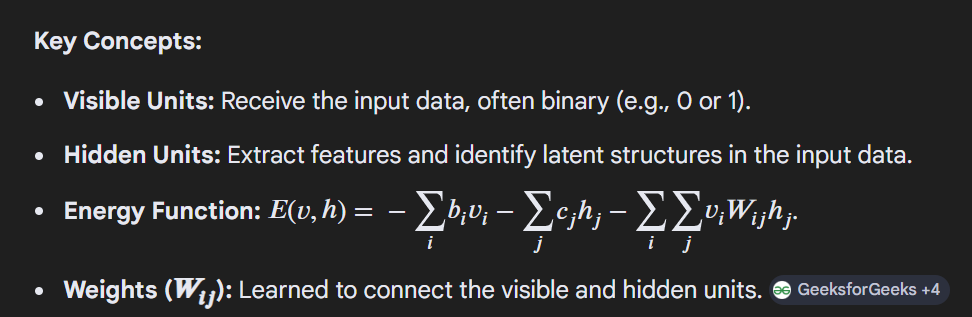



Boltzmann Machines are primarily divided into two categories: Energy-based Models (EBMs) and Restricted Boltzmann Machines (RBM). When these RBMs are stacked on top of each other, they are known as Deep Belief Networks (DBN).

**How RBM Works (Intuitively)**:
1. Input goes to visible layer
2. Hidden layer activates based on probabilities
3. Reconstruct input from hidden layer
4. Compare reconstruction with original
5. Update weights

This is called **Contrastive Divergence (CD)**.

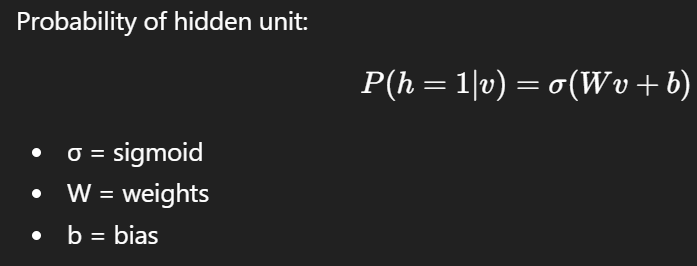

In [1]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Sample binary values
def sample(prob):
    return (prob > np.random.rand(*prob.shape)).astype(np.float32)

class RBM:
    def __init__(self, n_visible, n_hidden):
        self.W = np.random.normal(0, 0.01, (n_visible, n_hidden))
        self.h_bias = np.zeros(n_hidden)
        self.v_bias = np.zeros(n_visible)

    # Forward pass: visible -> hidden
    def hidden_prob(self, v):
        return sigmoid(np.dot(v, self.W) + self.h_bias)

    # Backward pass: hidden -> visible
    def visible_prob(self, h):
        return sigmoid(np.dot(h, self.W.T) + self.v_bias)

    def train(self, data, lr=0.1, epochs=1000):
        for epoch in range(epochs):
            # Positive phase
            h_prob = self.hidden_prob(data)
            h_sample = sample(h_prob)

            # Negative phase
            v_recon_prob = self.visible_prob(h_sample)
            h_recon_prob = self.hidden_prob(v_recon_prob)

            # Update weights
            self.W += lr * (np.dot(data.T, h_prob) - np.dot(v_recon_prob.T, h_recon_prob))
            self.v_bias += lr * np.mean(data - v_recon_prob, axis=0)
            self.h_bias += lr * np.mean(h_prob - h_recon_prob, axis=0)

            if epoch % 100 == 0:
                loss = np.mean((data - v_recon_prob) ** 2)
                print(f"Epoch {epoch}, Loss: {loss:.4f}")

In [2]:
# Dummy binary dataset
data = np.array([
    [1,1,1,0,0,0],
    [1,0,1,0,0,0],
    [1,1,1,0,0,0],
    [0,0,0,1,1,1],
    [0,0,0,1,0,1],
    [0,0,0,1,1,1]
])

rbm = RBM(n_visible=6, n_hidden=2)
rbm.train(data, epochs=1000)

Epoch 0, Loss: 0.2504
Epoch 100, Loss: 0.0391
Epoch 200, Loss: 0.0374
Epoch 300, Loss: 0.0372
Epoch 400, Loss: 0.0371
Epoch 500, Loss: 0.0371
Epoch 600, Loss: 0.0371
Epoch 700, Loss: 0.0371
Epoch 800, Loss: 0.0371
Epoch 900, Loss: 0.0370
